In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connected")

Connected


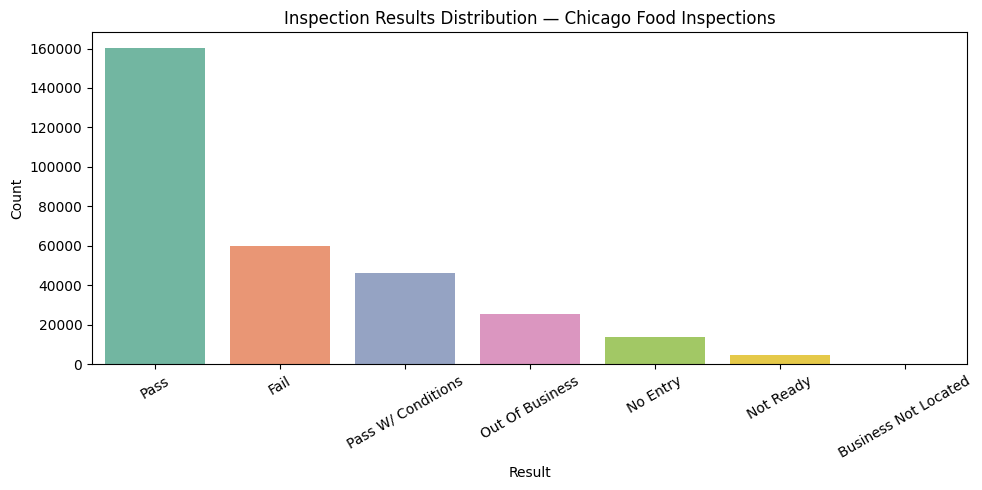

In [3]:
df_results = pd.read_sql("""
    SELECT results, COUNT(*) AS total
    FROM food_inspections
    GROUP BY results
    ORDER BY total DESC
""", engine)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x="results", y="total", hue="results", palette="Set2", legend=False)
plt.title("Inspection Results Distribution — Chicago Food Inspections")
plt.xlabel("Result")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

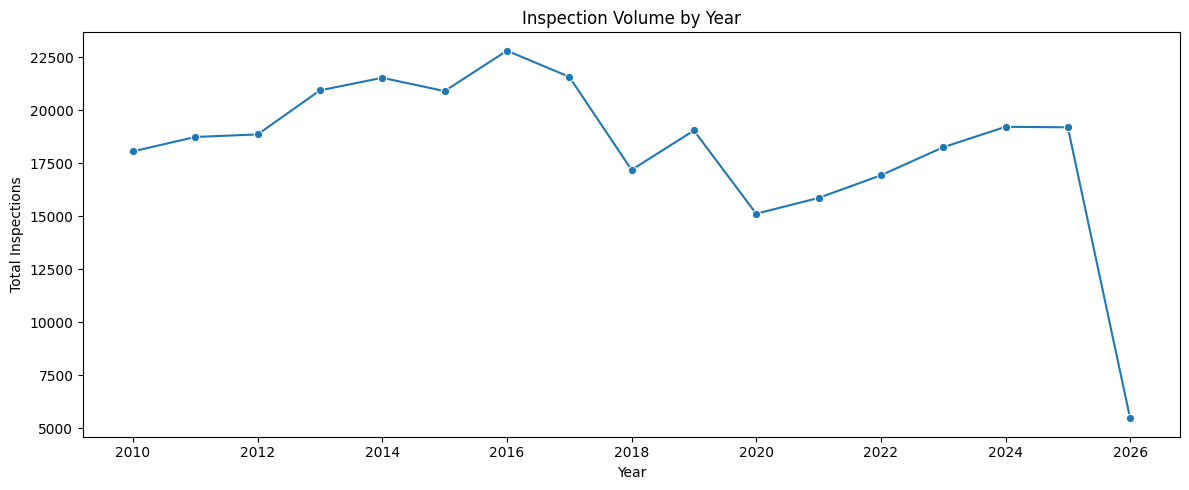

In [4]:
df_yearly = pd.read_sql("""
    SELECT inspection_year, COUNT(*) AS total_inspections
    FROM food_inspections
    WHERE inspection_year IS NOT NULL
    GROUP BY inspection_year
    ORDER BY inspection_year
""", engine)

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_yearly, x="inspection_year", y="total_inspections", marker="o")
plt.title("Inspection Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total Inspections")
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_5852\742325584.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_risk, x="risk_level", y="fail_rate_pct", palette="Reds_d")


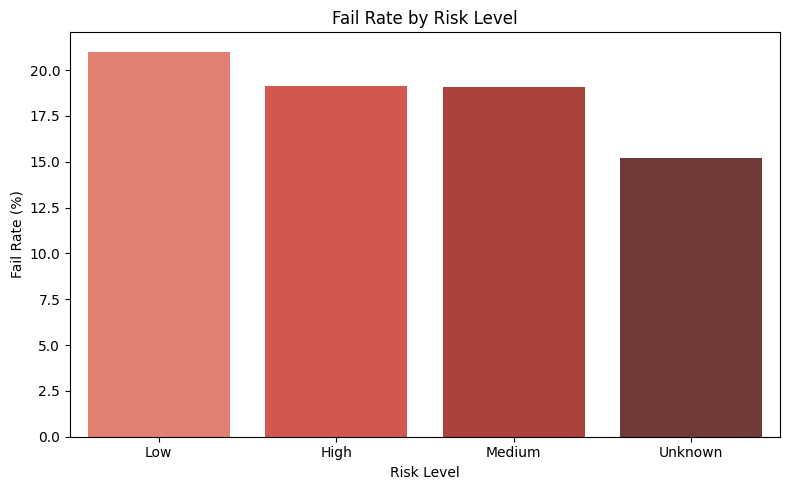

In [6]:
df_risk = pd.read_sql("""
    SELECT risk_level,
           ROUND(SUM(is_fail) * 100.0 / COUNT(*), 2) AS fail_rate_pct
    FROM food_inspections
    GROUP BY risk_level
""", engine)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_risk, x="risk_level", y="fail_rate_pct", hue="risk_level" palette="Reds_d")
plt.title("Fail Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Fail Rate (%)")
plt.tight_layout()
plt.show()